<a href="https://colab.research.google.com/github/silviyax03/Amazon-Music-Clustering-/blob/main/Amazon_Music_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Music Clustering

## 1. Project Overview

### Domain
Music Analytics / Unsupervised Machine Learning

### Objective
To group songs with similar audio characteristics using K-Means
clustering and identify meaningful audio-profile clusters without
using predefined genre labels.

### Problem Statement
With a large number of songs available on music platforms, manually
categorizing tracks into genres or musical profiles is impractical.
This project uses unsupervised machine learning to group songs based
on audio characteristics such as danceability, energy, loudness,
speechiness, acousticness, instrumentalness, liveness, valence,
tempo, and duration.

The resulting clusters can support personalized playlist curation,
song discovery, artist analysis, and market segmentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/single_genre_artists.csv")
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [3]:
df.shape

(95837, 23)

In [4]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [6]:
# Check for missing values
df.isnull().sum()

,0
id_songs,0
name_song,0
popularity_songs,0
duration_ms,0
explicit,0
id_artists,0
release_date,0
danceability,0
energy,0
key,0


In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Look at numerical statistics
df.describe()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000000,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
std,16.254133,1.177526e+05,0.169604,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833
min,0.000000,6.373000e+03,0.000000,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000


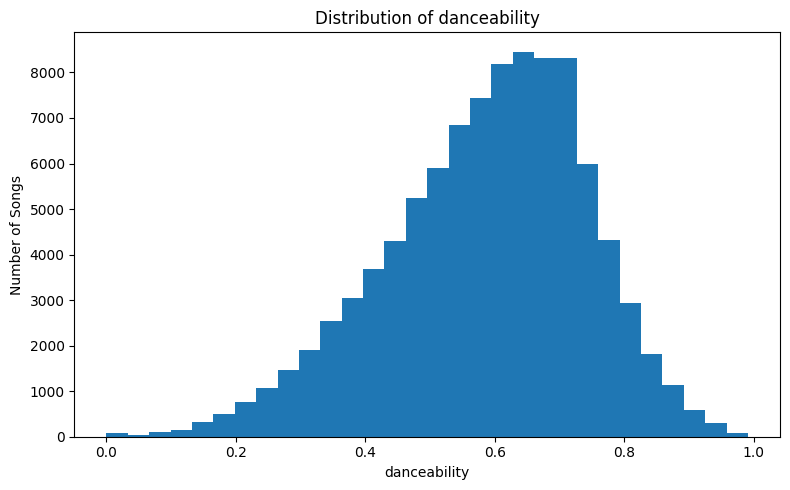

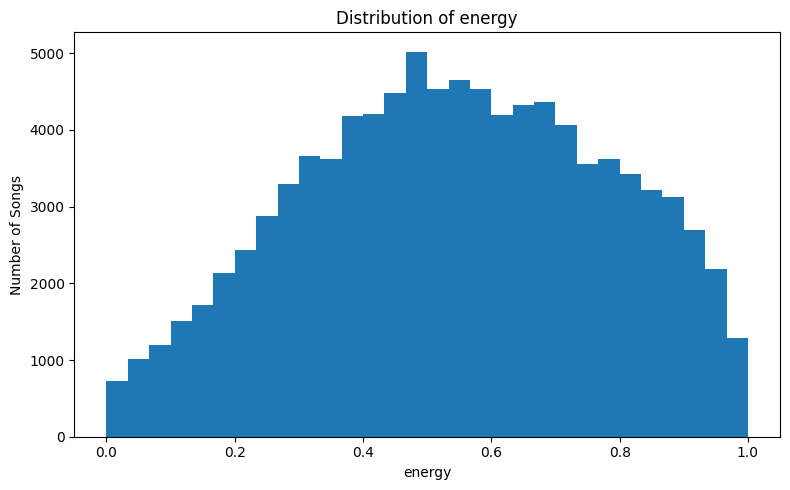

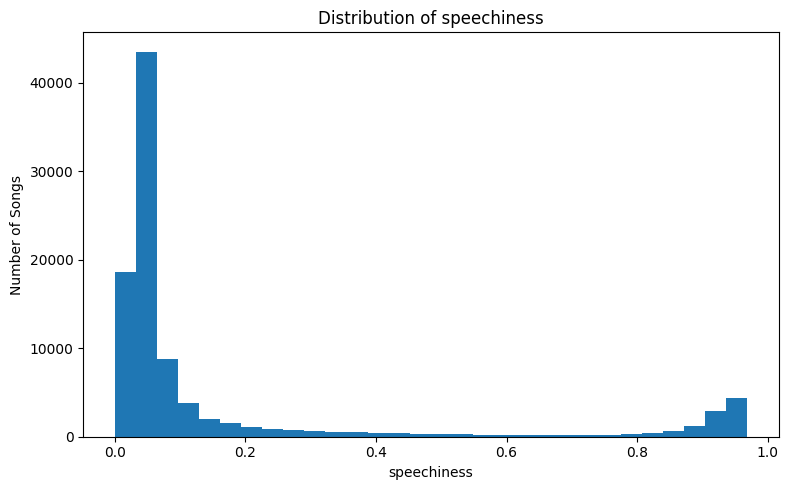

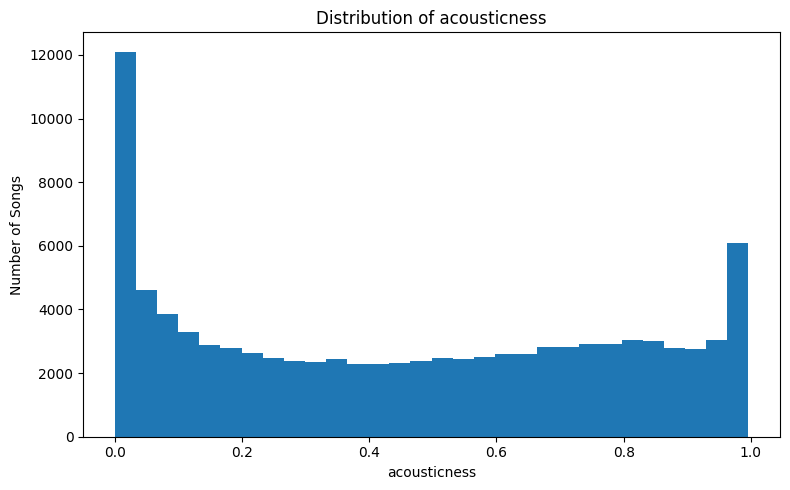

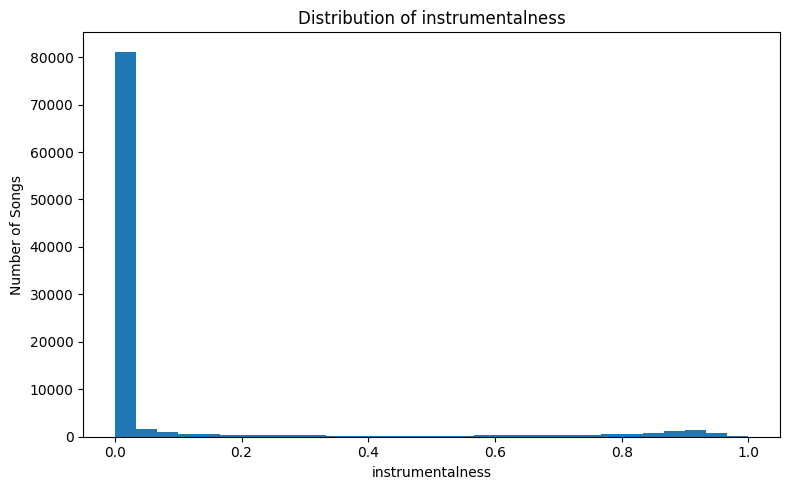

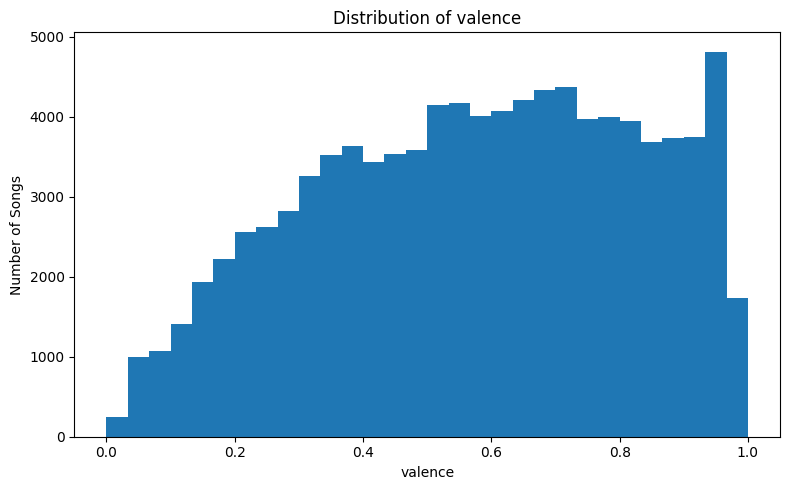

In [9]:
# Plot distributions of selected audio features

selected_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "valence"
]

for feature in selected_features:
    plt.figure(figsize=(8, 5))

    plt.hist(df[feature], bins=30)

    plt.xlabel(feature)
    plt.ylabel("Number of Songs")
    plt.title(f"Distribution of {feature}")

    plt.tight_layout()
    plt.show()

In [10]:
# Check the unique values of important categorical/binary columns
print("Explicit values:")
print(df["explicit"].value_counts())

print("\nKey values:")
print(df["key"].value_counts().sort_index())

print("\nMode values:")
print(df["mode"].value_counts())

print("\nTime signature values:")
print(df["time_signature"].value_counts().sort_index())

Explicit values:
explicit
0    92996
1     2841
Name: count, dtype: int64

Key values:
key
0     12357
1      7314
2     10906
3      3222
4      7648
5      8896
6      5041
7     11967
8      5392
9     10421
10     6163
11     6510
Name: count, dtype: int64

Mode values:
mode
1    62109
0    33728
Name: count, dtype: int64

Time signature values:
time_signature
0       85
1     1573
3    12095
4    79175
5     2909
Name: count, dtype: int64


In [11]:
# Create the feature dataset
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

X = df[features]

In [12]:
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973


In [13]:
X.shape

(95837, 10)

In [14]:
X.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04
mean,0.586853,0.541083,-10.157862,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,2.087320e+05
std,0.155422,0.236304,4.748798,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,1.177526e+05
min,0.000000,0.000020,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.373000e+03
25%,0.488000,0.365000,-12.723000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,1.573330e+05
50%,0.605000,0.542000,-9.397000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,2.040000e+05
75%,0.700000,0.727000,-6.692000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,2.502670e+05
max,0.991000,1.000000,5.376000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,4.800118e+06


In [15]:
# Standardize the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled.shape

(95837, 10)

In [17]:
X_scaled[:5]

array([[-0.15347598, -1.51112816, -0.75790895, -0.42710882,  1.61618723,
        -0.35333823,  0.53858362,  0.32128698,  0.51500516, -0.40173462],
       [-1.02851842, -1.52805562, -1.09862851, -0.36974088,  1.60408122,
        -0.35340491, -0.52153664, -0.57745518, -1.2944868 ,  0.12490637],
       [-0.48805103, -1.41802711, -1.12789922, -0.39806176,  1.62224024,
        -0.35340491,  1.03904648, -0.37594348, -1.56000306, -0.00394925],
       [ 0.57358134, -0.31351008, -0.4706769 , -0.01391443,  1.61013423,
        -0.35340491, -0.03183642,  0.61146382,  0.40526772, -0.39743745],
       [ 0.40629381, -1.02869543, -0.76822741, -0.11194825,  1.61013423,
        -0.35340491,  0.79688703,  1.08703142, -1.37759312, -0.34614318]])

In [18]:
# Verify the scaling
import numpy as np

print("Mean of scaled features:")
print(np.mean(X_scaled, axis=0))

print("\nStandard deviation of scaled features:")
print(np.std(X_scaled, axis=0))

Mean of scaled features:
[ 2.74617350e-16  5.45675943e-17  4.03325697e-17 -4.98225861e-17
  2.27760394e-16 -4.03325697e-17 -3.79600656e-17  3.91463177e-17
 -2.07594109e-16 -5.21950902e-17]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [19]:
# Import libraries
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different values of K
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Display inertia values
print("Inertia values:")
for k, value in zip(range(2, 11), inertia):
    print(f"k={k}: {value:.2f}")

Inertia values:
k=2: 778813.59
k=3: 658335.08
k=4: 593031.03
k=5: 548594.92
k=6: 520710.60
k=7: 486936.40
k=8: 460215.41
k=9: 439036.66
k=10: 415491.73


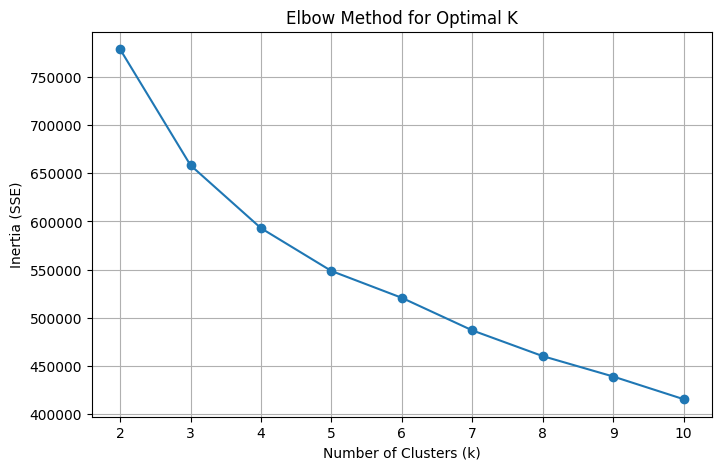

In [20]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [21]:
# Import silhouette score
from sklearn.metrics import silhouette_score

# Create a random sample for faster silhouette calculation
sample_size = 10000

sample_indices = np.random.RandomState(42).choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

# Calculate silhouette scores for different values of K
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

# Display silhouette scores
print("Silhouette Scores:")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {score:.4f}")

Silhouette Scores:
k=2: 0.1977
k=3: 0.2364
k=4: 0.2262
k=5: 0.1865
k=6: 0.1857
k=7: 0.1866
k=8: 0.1671
k=9: 0.1639
k=10: 0.1735


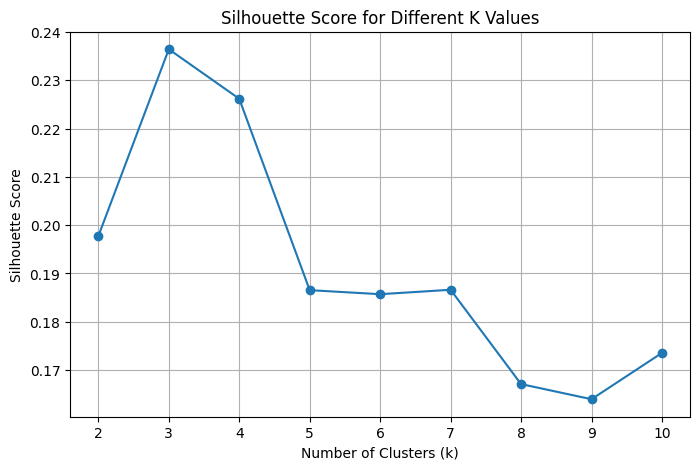

In [22]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [23]:
# Create final K-Means model
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit the model and generate cluster labels
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the original dataset
df["cluster"] = cluster_labels

In [24]:
# Check number of songs in each cluster
df["cluster"].value_counts().sort_index()

,count
cluster,
0,12513
1,30807
2,52517


In [25]:
# Calculate average audio features for each cluster
cluster_profile = df.groupby("cluster")[features].mean()

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.664271,0.466636,-13.363885,0.829978,0.585932,0.001385,0.435535,0.584036,100.389473,97520.590026
1,0.486381,0.311231,-13.205013,0.060140,0.749228,0.168547,0.182070,0.413254,111.939598,223457.063979
2,0.627345,0.693655,-7.606487,0.075064,0.258485,0.050703,0.199867,0.666416,124.911397,226592.052516


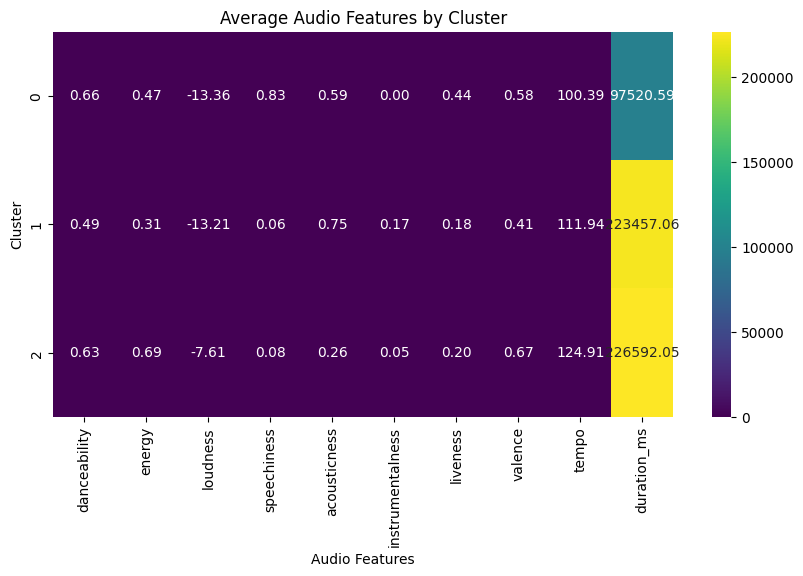

In [26]:
# Import visualization library
import seaborn as sns

# Plot cluster feature averages
plt.figure(figsize=(10, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Average Audio Features by Cluster")
plt.xlabel("Audio Features")
plt.ylabel("Cluster")

plt.show()

In [27]:
# Import PCA
from sklearn.decomposition import PCA

# Reduce the features to 2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("PCA components:", X_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original features: 10
PCA components: 2
Explained variance ratio: [0.27079553 0.18821441]
Total explained variance: 0.459009939910359


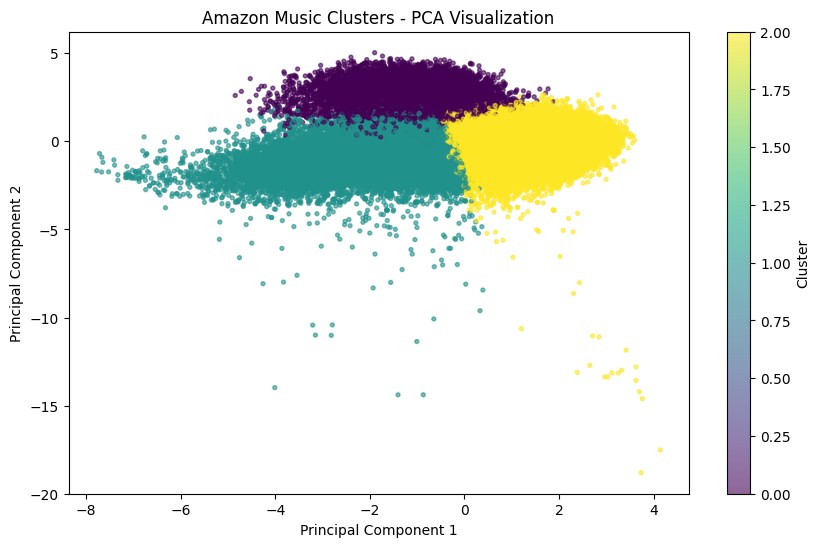

In [28]:
# Plot clusters in 2D using PCA
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    cmap="viridis",
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Amazon Music Clusters - PCA Visualization")

plt.colorbar(label="Cluster")

plt.show()

In [29]:
# Import evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate final evaluation metrics
final_silhouette = silhouette_score(X_scaled, df["cluster"])
final_db_index = davies_bouldin_score(X_scaled, df["cluster"])
final_inertia = kmeans_final.inertia_

# Display results
print("Final Evaluation Metrics")
print("------------------------")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Davies-Bouldin Index: {final_db_index:.4f}")
print(f"Inertia: {final_inertia:.2f}")

Final Evaluation Metrics
------------------------
Silhouette Score: 0.2423
Davies-Bouldin Index: 1.5702
Inertia: 658335.08


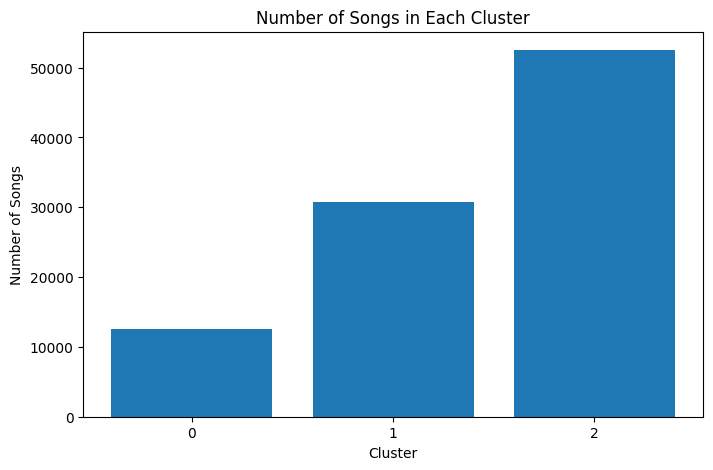

In [30]:
# Plot cluster sizes
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.title("Number of Songs in Each Cluster")

plt.show()

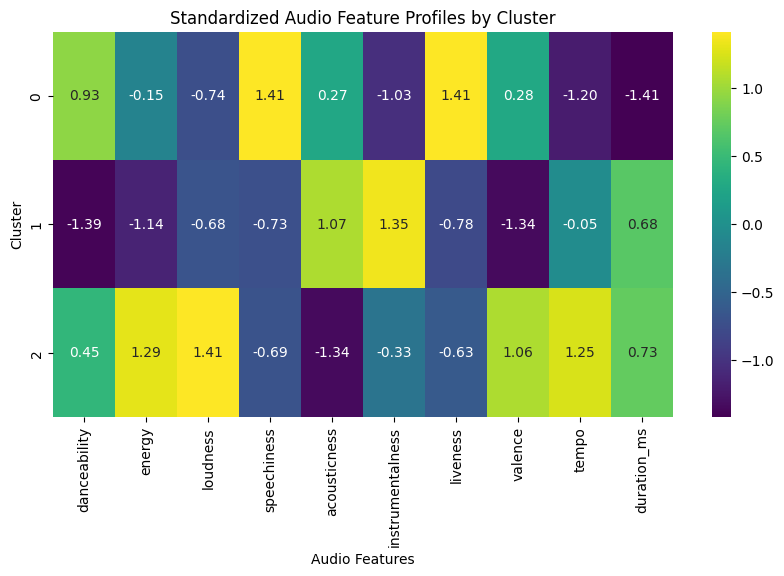

In [31]:
# Standardize cluster profiles for visualization
from sklearn.preprocessing import StandardScaler

cluster_profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

# Plot standardized cluster profiles
plt.figure(figsize=(10, 5))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0
)

plt.title("Standardized Audio Feature Profiles by Cluster")
plt.xlabel("Audio Features")
plt.ylabel("Cluster")

plt.show()

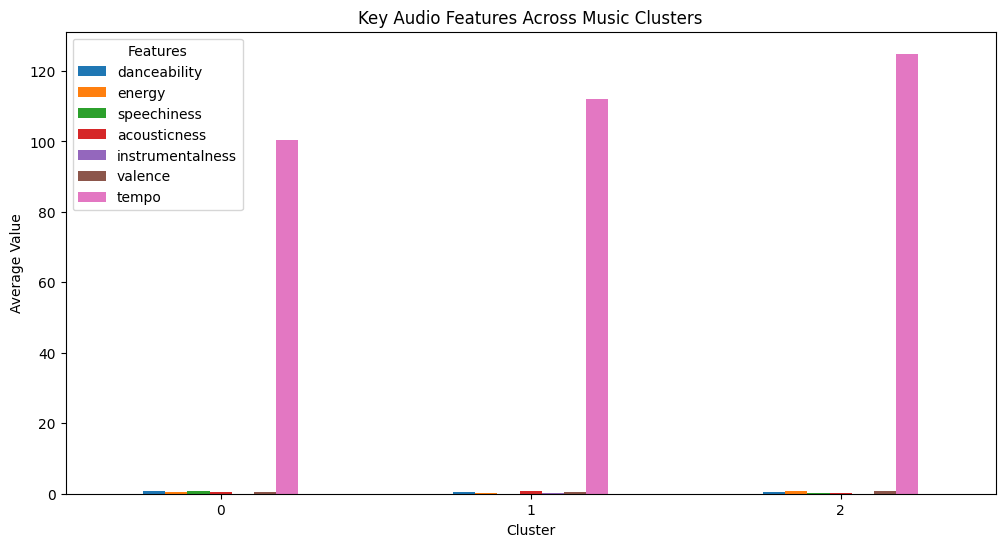

In [32]:
# Compare key audio features across clusters
key_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "valence",
    "tempo"
]

cluster_profile[key_features].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Key Audio Features Across Music Clusters")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Features")

plt.show()

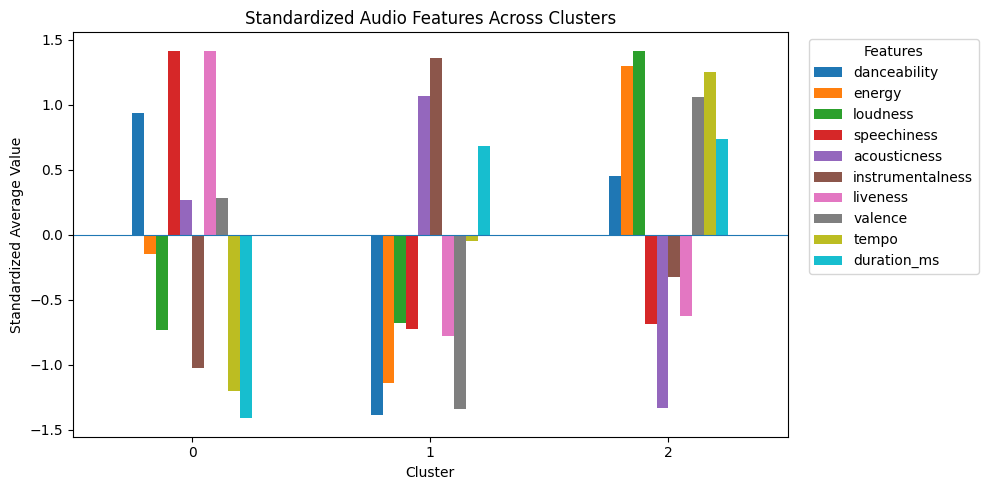

In [33]:
# Plot standardized feature comparison
cluster_profile_scaled.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Standardized Audio Features Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Standardized Average Value")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=0.8)

plt.legend(title="Features", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [34]:
# Display sample songs from each cluster
for cluster in sorted(df["cluster"].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 50)

    display(
        df[df["cluster"] == cluster][
            ["name_song", "name_artists", "genres"]
        ].head(10)
    )


Cluster 0
--------------------------------------------------


,name_song,name_artists,genres
37,Dites Moi Doumergue,Perchicot,['vintage chanson']
43,Il N'osait Pas Se Decider,Georgius,['vintage chanson']
50,L'amour Excuse Tout,Georgius,['vintage chanson']
55,Le Genre De La Maison,Georgius,['vintage chanson']
58,Le Piéton,Georgius,['vintage chanson']
60,Oh Oh Il Travaille Du Chapeau,Georgius,['vintage chanson']
63,C'est Jeune Et Ca N'sait Pas,Fortugé,['vintage chanson']
104,Big Fat Ma and Skinny Pa,Louis Armstrong & His Hot Five,['new orleans jazz']
108,Big Fat Ma And Skinny Pa,Louis Armstrong & His Hot Five,['new orleans jazz']
146,A Monday Date,Louis Armstrong & His Hot Five,['new orleans jazz']



Cluster 1
--------------------------------------------------


,name_song,name_artists,genres
0,La Java,Mistinguett,['vintage chanson']
1,En Douce,Mistinguett,['vintage chanson']
2,J'en Ai Marre,Mistinguett,['vintage chanson']
3,Ils n'ont pas ca,Mistinguett,['vintage chanson']
4,La belote,Mistinguett,['vintage chanson']
5,Oh mademoiselle,Mistinguett,['vintage chanson']
6,Il m'a vue nue,Mistinguett,['vintage chanson']
7,Mon Bus'ness,Mistinguett,['vintage chanson']
8,Ça c'est Paris,Mistinguett,['vintage chanson']
9,Le Fado,Mistinguett,['vintage chanson']



Cluster 2
--------------------------------------------------


,name_song,name_artists,genres
15,On M'suit,Mistinguett,['vintage chanson']
34,Je N'suis Pas Celle Que Vous Croyez,Perchicot,['vintage chanson']
38,La Noce À Rebecca,Perchicot,['vintage chanson']
128,Hotter Than That,Louis Armstrong & His Hot Five,['new orleans jazz']
152,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,['new orleans jazz']
188,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,['new orleans jazz']
199,Hotter Than That,Louis Armstrong & His Hot Five,['new orleans jazz']
200,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,['new orleans jazz']
215,Hotter Than That,Louis Armstrong & His Hot Five,['new orleans jazz']
230,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,['new orleans jazz']


In [35]:
# Find songs closest to each cluster center
distances = kmeans_final.transform(X_scaled)

for cluster in range(3):
    cluster_indices = np.where(df["cluster"].values == cluster)[0]

    # Get distances of songs belonging to this cluster from its centroid
    cluster_distances = distances[cluster_indices, cluster]

    # Select the 10 closest songs
    closest_indices = cluster_indices[np.argsort(cluster_distances)[:10]]

    print(f"\nCluster {cluster}")
    print("-" * 50)

    display(
        df.loc[
            closest_indices,
            ["name_song", "name_artists", "genres"]
        ]
    )


Cluster 0
--------------------------------------------------


,name_song,name_artists,genres
22666,"066 - Gauner mit der ""Goldenen Hand"" - Teil 19",TKKG Retro-Archiv,['kleine hoerspiel']
22525,058 - Der doppelte Pedro - Teil 02,TKKG Retro-Archiv,['kleine hoerspiel']
16461,008 - und der grüne Geist - Teil 15,Die drei ???,['hoerspiel']
21998,004 - Das Paket mit dem Totenkopf - Teil 23,TKKG Retro-Archiv,['kleine hoerspiel']
13177,Kapitel 25 - als Gärtner (Folge 047),Benjamin Blümchen,['hoerspiel']
20655,Kapitel 10 - Die Wahrsagerin (Folge 063),Bibi Blocksberg,['hoerspiel']
18617,103 - Das Erbe des Meisterdiebes - Teil 14,Die drei ???,['hoerspiel']
16434,008 - und der grüne Geist - Teil 11,Die drei ???,['hoerspiel']
22003,002 - Der blinde Hellseher - Teil 23,TKKG Retro-Archiv,['kleine hoerspiel']
17838,080 - Geheimakte Ufo - Teil 29,Die drei ???,['hoerspiel']



Cluster 1
--------------------------------------------------


,name_song,name_artists,genres
94051,Tata lata,Jan Ptaszyn Wróblewski,['polish jazz']
20891,นกนางนวล,Chatree,['classic thai pop']
8725,Laura - Tell Laura I Love Her,Hector,"['classic finnish pop', 'classic finnish rock'..."
77457,Hangi Yol,Cihan Mürtezaoğlu,['turkish alt pop']
6792,Cristal / En Esta Tarde Gris,Orquestra Românticos de Cuba,['romantico']
6950,Three King Fishers,Donovan,"['art rock', 'brill building pop', 'british fo..."
45595,ブランデーグラス,Yujiro Ishihara,['enka']
67214,Povero Core,Peppino Gagliardi,['classic italian pop']
43610,הדרך אל הכפר,Rivka Zohar,['classic israeli pop']
4453,Scheherezade,Jerry Murad's Harmonicats,['lounge']



Cluster 2
--------------------------------------------------


,name_song,name_artists,genres
48633,Om du kommer tillbaks,Ratata,['classic swedish pop']
55979,אני אוהב אותך ממש מוגזם,Teapacks,['israeli pop']
53878,Musica,Paolo Meneguzzi,['italian adult pop']
91416,Korraks,The Tuberkuloited,['estonian rock']
5132,Le Rideau rouge,Gilbert Bécaud,['chanson']
24486,Into My Dreams,Jennifer Rush,['new wave pop']
12600,Bir Kuş Uçur,Sezen Aksu,['turkish pop']
28043,Sempre,Paolo Vallesi,['italian adult pop']
57490,Escancarando De Vez (Eu E Você),Elymar Santos,['pop nacional antigas']
7987,Kıskanırım,Erkin Koray,['anadolu rock']


In [36]:
# Check genre values
df["genres"].head(10)

,genres
0,['vintage chanson']
1,['vintage chanson']
2,['vintage chanson']
3,['vintage chanson']
4,['vintage chanson']
5,['vintage chanson']
6,['vintage chanson']
7,['vintage chanson']
8,['vintage chanson']
9,['vintage chanson']


In [37]:
# Convert genre strings into Python lists
import ast

df["genres_list"] = df["genres"].apply(ast.literal_eval)

In [38]:
# Check converted genre values
df["genres_list"].head()

,genres_list
0,[vintage chanson]
1,[vintage chanson]
2,[vintage chanson]
3,[vintage chanson]
4,[vintage chanson]


In [39]:
# Count the most common genres in each cluster
for cluster in sorted(df["cluster"].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 50)

    genre_counts = (
        df[df["cluster"] == cluster]["genres_list"]
        .explode()
        .value_counts()
        .head(10)
    )

    display(genre_counts.to_frame("count"))


Cluster 0
--------------------------------------------------


,count
genres_list,
hoerspiel,7564
kleine hoerspiel,2005
psychedelic rock,220
barnsagor,185
poetry,166
barnmusik,141
classic israeli pop,86
kindermusik,84
barnasogur,76



Cluster 1
--------------------------------------------------


,count
genres_list,
vintage taiwan pop,1131
classic israeli pop,592
chanson,550
classic soundtrack,456
classic thai pop,428
opm,407
indonesian pop,406
rebetiko,356
turkish folk,348



Cluster 2
--------------------------------------------------


,count
genres_list,
j-pop,878
turkish pop,683
classic thai pop,649
thai pop,581
classic israeli pop,553
rock uruguayo,521
indonesian pop,515
cumbia uruguaya,486
slovak pop,471


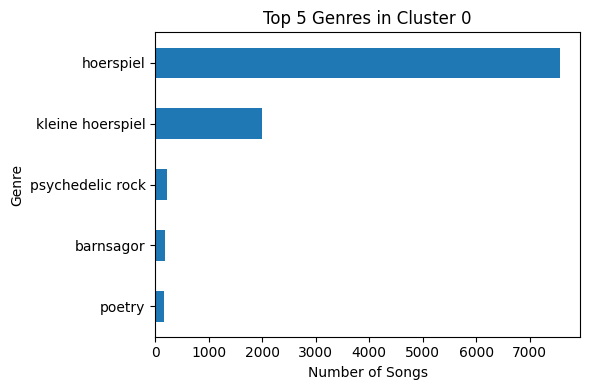

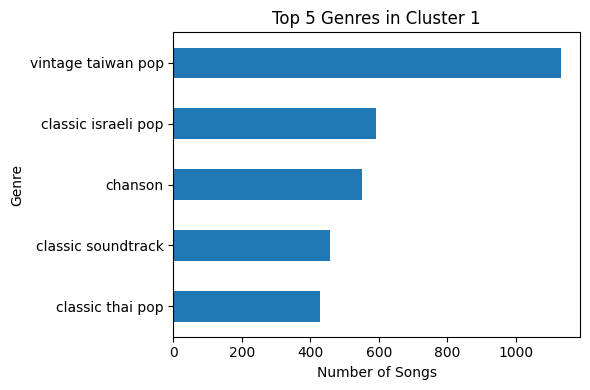

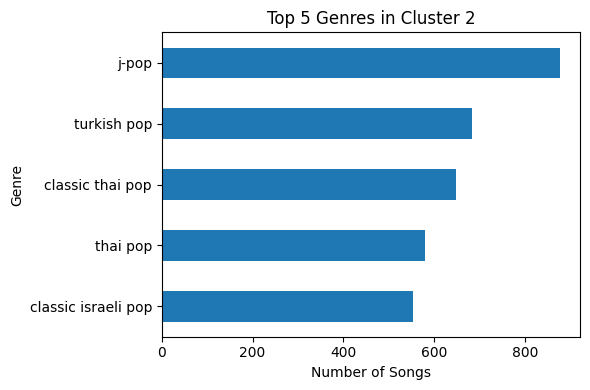

In [40]:
# Plot top genres for each cluster
for cluster in sorted(df["cluster"].unique()):
    genre_counts = (
        df[df["cluster"] == cluster]["genres_list"]
        .explode()
        .value_counts()
        .head(5)
        .sort_values()
    )

    plt.figure(figsize=(6, 4))

    genre_counts.plot(kind="barh")

    plt.title(f"Top 5 Genres in Cluster {cluster}")
    plt.xlabel("Number of Songs")
    plt.ylabel("Genre")

    plt.tight_layout()
    plt.show()

In [41]:
# Create cluster summary
cluster_summary = cluster_profile.copy()

cluster_summary["song_count"] = df["cluster"].value_counts().sort_index()

cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,song_count
cluster,,,,,,,,,,,
0,0.664271,0.466636,-13.363885,0.829978,0.585932,0.001385,0.435535,0.584036,100.389473,97520.590026,12513
1,0.486381,0.311231,-13.205013,0.060140,0.749228,0.168547,0.182070,0.413254,111.939598,223457.063979,30807
2,0.627345,0.693655,-7.606487,0.075064,0.258485,0.050703,0.199867,0.666416,124.911397,226592.052516,52517


In [42]:
# Display cluster summary
display(cluster_summary)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,song_count
cluster,,,,,,,,,,,
0,0.664271,0.466636,-13.363885,0.829978,0.585932,0.001385,0.435535,0.584036,100.389473,97520.590026,12513
1,0.486381,0.311231,-13.205013,0.060140,0.749228,0.168547,0.182070,0.413254,111.939598,223457.063979,30807
2,0.627345,0.693655,-7.606487,0.075064,0.258485,0.050703,0.199867,0.666416,124.911397,226592.052516,52517


## Business Insights

### Cluster 0 — Speech / Spoken-Content Profile
- Very high speechiness.
- Shorter average duration.
- Strong association with spoken-content genres.
- Useful for spoken-content or storytelling playlist segmentation.

### Cluster 1 — Acoustic / Instrumental Profile
- High acousticness and instrumentalness.
- Lower energy and valence.
- Useful for calm, acoustic, or background-music playlist curation.

### Cluster 2 — Energetic / Upbeat Profile
- High energy, loudness, valence, and tempo.
- Suitable for energetic and upbeat listening experiences.
- Useful for activity-based or high-energy playlist recommendations.

### Business Applications
- Personalized playlist curation
- Similar-song discovery
- Artist and content analysis
- Music-content segmentation

> Genre labels were used only for post-clustering interpretation. They were not used as input features for K-Means.

## Final Results

### Dataset
- Total songs analyzed: **95,837**
- Audio features used for clustering: **10**
- Clustering algorithm: **K-Means**
- Number of clusters selected: **3**

### Model Selection
- Elbow Method was used to examine cluster compactness.
- Silhouette analysis on a random sample identified **K = 3** as the best-performing option.

### Final Model Evaluation
- Silhouette Score: **0.2423**
- Davies-Bouldin Index: **1.5702**
- Inertia: **658,335.08**

### PCA
- Two principal components were used for visualization.
- Explained variance by PC1: **27.08%**
- Explained variance by PC2: **18.82%**
- Total explained variance: **45.90%**

### Cluster Distribution
- Cluster 0: **12,513 songs**
- Cluster 1: **30,807 songs**
- Cluster 2: **52,517 songs**

## Conclusion

The Amazon Music Clustering project used unsupervised machine learning
to group 95,837 songs according to their audio characteristics.

Ten standardized audio features were used as the input to K-Means
clustering. Based on the Elbow Method and Silhouette analysis, three
clusters were selected for the final model.

The resulting clusters represent different audio profiles. Cluster 0
is strongly associated with speech-heavy content, Cluster 1 with
acoustic and instrumental characteristics, and Cluster 2 with more
energetic and upbeat characteristics.

Genre information was used only after clustering to help interpret the
clusters. The analysis showed that individual clusters can contain
multiple genres that share similar audio characteristics.

The resulting clusters can support personalized playlist curation,
song discovery, artist analysis, and music-content segmentation.

In [43]:
# Export the final clustered dataset
output_file = "amazon_music_clustered.csv"

df.to_csv(output_file, index=False)

print(f"Dataset saved as: {output_file}")

Dataset saved as: amazon_music_clustered.csv


In [45]:
# Check the exported file
import os

print("File exists:", os.path.exists(output_file))
print("File size:", os.path.getsize(output_file) / (1024 * 1024), "MB")

File exists: True
File size: 20.227521896362305 MB
